In [75]:
import torch
from torch import nn
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
NUM_CLASSES=4
NUM_FEATURES=2
RANDOM_SEED=42
X_blob,y_blob=make_blobs(n_samples=1000,n_features=NUM_FEATURES,cluster_std=1.5,centers=NUM_CLASSES,random_state=RANDOM_SEED)


In [76]:
X_blob=torch.from_numpy(X_blob).type(torch.float)
y_blob=torch.from_numpy(y_blob).type(torch.long)
X_blob_train,X_blob_test,y_blob_train,y_blob_test=train_test_split(
        X_blob,y_blob,test_size=0.2,random_state=RANDOM_SEED 
        )


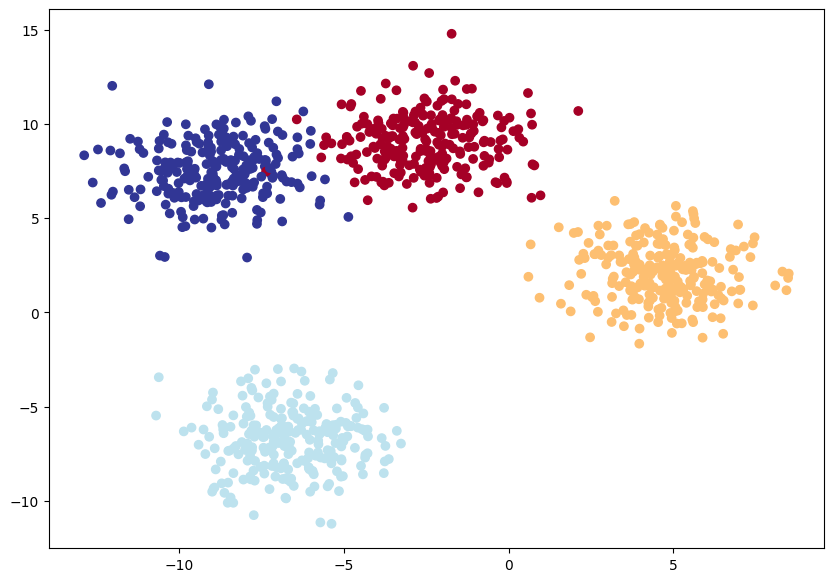

In [77]:
plt.figure(figsize=(10,7))
plt.scatter(X_blob[:,0],X_blob[:,1],c=y_blob,cmap=plt.cm.RdYlBu)

In [86]:
class MultiCLassClassification(nn.Module):
    def __init__(self):
        super().__init__()
        self.three_linear_layer=nn.Sequential(
            nn.Linear(in_features=2,out_features=10),
            nn.ReLU(),
            nn.Linear(in_features=10,out_features=5),
            nn.ReLU(),
            nn.Linear(in_features=5,out_features=NUM_CLASSES)
        )
    def forward(self,x):
        return self.three_linear_layer(x)
model=MultiCLassClassification()
model

MultiCLassClassification(
  (three_linear_layer): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=5, bias=True)
    (3): ReLU()
    (4): Linear(in_features=5, out_features=4, bias=True)
  )
)

In [87]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model.parameters(),lr=0.01)

In [98]:
epochs=100
test_loss_v=[]
train_loss_v=[]
epoch_count = []
for epoch in range(epochs):
    model.train()
    y_train_pred=model(X_blob_train)
    loss=loss_fn(y_train_pred,y_blob_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    model.eval()
    with torch.inference_mode():
        y_test_pred=model(X_blob_test)
        y_loss=loss_fn(y_test_pred,y_blob_test)
        if epoch%10==0:
            epoch_count.append(epoch)
            train_loss_v.append(loss.detach().numpy())
            test_loss_v.append(y_loss.detach().numpy())
            print(f"Train loss {loss} || Test Loss {y_loss} || epoch {epoch} ")
            # print(model.state_dict())

Train loss 0.1618109941482544 || Test Loss 0.1542397439479828 || epoch 0 
Train loss 0.1500864326953888 || Test Loss 0.14297370612621307 || epoch 10 
Train loss 0.13927966356277466 || Test Loss 0.13252146542072296 || epoch 20 
Train loss 0.12948544323444366 || Test Loss 0.12301100045442581 || epoch 30 
Train loss 0.12070699781179428 || Test Loss 0.11443554610013962 || epoch 40 
Train loss 0.11289183795452118 || Test Loss 0.10674653947353363 || epoch 50 
Train loss 0.10595475137233734 || Test Loss 0.09988696128129959 || epoch 60 
Train loss 0.0998324453830719 || Test Loss 0.09383268654346466 || epoch 70 
Train loss 0.09442759305238724 || Test Loss 0.08848880976438522 || epoch 80 
Train loss 0.08965475112199783 || Test Loss 0.08375798910856247 || epoch 90 


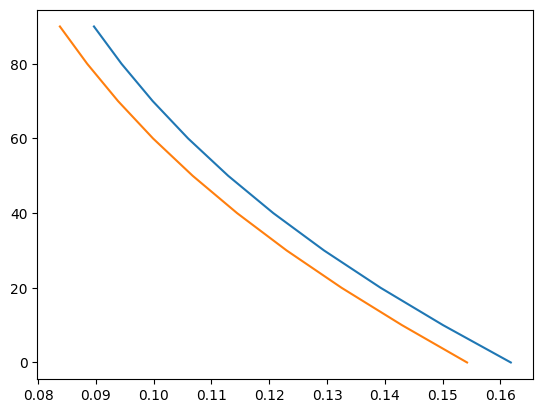

In [99]:
plt.plot(train_loss_v,epoch_count,label="Train loss")
plt.plot(test_loss_v,epoch_count,label="Test loss")